# Industrial Refrigeration Analysis — Part 2: Scenario Analysis of the Humidity Effect

Part 1 established the setup: temperature dominates mould cooling time, and humidity — if it
matters at all — is a small effect entangled with temperature. This notebook asks whether
that humidity effect can be **isolated and trusted**.

The strategy is not one global regression (which would be dominated and confounded by
temperature) but a **scenario-based analysis**: detect stable operating periods, classify
each by a correlation/collinearity rule, and fit a family of regressions within each. Four
scenarios, each answering a different question:

- **V1** — where temperature strongly drives cooling time. *Reference: confirm thermal dominance.*
- **V2** — where that correlation is weak. *Does anything else surface — and is it humidity?*
- **V3** — where temperature and **relative** humidity decouple. *Estimate HR cleanly.*
- **V4** — where temperature and **absolute** humidity decouple. *Estimate HA cleanly.*

## 1. Scenario criteria

Each candidate period is classified by transparent thresholds on Pearson correlations and
the variance inflation factor `VIF = 1/(1 - r²)` — no hidden model, every decision checkable
by hand:

| Scenario | Criterion | Purpose |
|---|---|---|
| **V1** | `|corr(TR, T)| ≥ 0.35` | temperature clearly drives cooling time |
| **V2** | `|corr(TR, T)| ≤ 0.40` | temperature does not — look for other effects |
| **V3** | `|corr(T, HR)| ≤ 0.40` and `VIF_HR ≤ 1.20` | T and relative humidity separable |
| **V4** | `|corr(T, HA)| ≤ 0.40` and `VIF_HA ≤ 1.20` | T and absolute humidity separable |

`TR` = cooling time, `T` = duct temperature, `HR` = relative humidity, `HA` = absolute humidity.

## 2. Setup and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("synthetic_global.csv", sep=";", decimal=",")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df = df.rename(columns={"cooling_time_s":"TR", "duct_temp_C":"T",
                        "duct_rh_pct":"HR", "abs_humidity_gm3":"HA"})
print(f"{len(df):,} rows, {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
df[["timestamp","period","TR","T","HR","HA"]].head()

7,910 rows, 2022-09-01 to 2022-11-26


,timestamp,period,TR,T,HR,HA
0,2022-09-01 00:00:00,P1,160.875632,31.876245,28.647529,9.589733
1,2022-09-01 00:15:00,P1,177.061543,33.374130,23.767809,8.614523
2,2022-09-01 00:30:00,P1,166.036334,31.388239,28.277847,9.222191
3,2022-09-01 00:45:00,P1,151.032814,28.121525,35.463307,9.687867
4,2022-09-01 01:00:00,P1,158.388639,31.884760,28.503913,9.545994


## 3. Detecting operating periods

Correlations must be computed within a continuous run, never across a gap, or two unrelated
regimes blend. A gap over 4 hours starts a new block.

In [2]:
df["gap_h"] = df["timestamp"].diff().dt.total_seconds() / 3600
df["block"] = (df["gap_h"] > 4).cumsum()
blocks = [g for _, g in df.groupby("block") if g["timestamp"].dt.date.nunique() >= 4]
print(f"Continuous blocks detected: {len(blocks)}")
for g in blocks:
    print(f"  {g['period'].iloc[0]}: {g['timestamp'].min().date()} -> {g['timestamp'].max().date()}"
          f"  ({g['timestamp'].dt.date.nunique()} days, {len(g):,} rows)")

Continuous blocks detected: 6
  P1: 2022-09-01 -> 2022-09-14  (14 days, 1,309 rows)
  P2: 2022-09-15 -> 2022-09-29  (15 days, 1,321 rows)
  P3: 2022-09-29 -> 2022-10-13  (15 days, 1,321 rows)
  P4: 2022-10-14 -> 2022-10-28  (15 days, 1,315 rows)
  P5: 2022-10-28 -> 2022-11-11  (15 days, 1,327 rows)
  P6: 2022-11-12 -> 2022-11-26  (15 days, 1,317 rows)


## 4. Classifying the periods

In [3]:
V1_MIN, V2_MAX, CORR_MAX, VIF_MAX = 0.35, 0.40, 0.40, 1.20

def classify(g):
    r_TR_T = stats.pearsonr(g["TR"], g["T"])[0]
    r_T_HR = stats.pearsonr(g["T"],  g["HR"])[0]
    r_T_HA = stats.pearsonr(g["T"],  g["HA"])[0]
    vif_HR, vif_HA = 1/(1 - r_T_HR**2), 1/(1 - r_T_HA**2)
    v = []
    if abs(r_TR_T) >= V1_MIN:                          v.append("V1")
    if abs(r_TR_T) <= V2_MAX:                          v.append("V2")
    if abs(r_T_HR) <= CORR_MAX and vif_HR <= VIF_MAX:  v.append("V3")
    if abs(r_T_HA) <= CORR_MAX and vif_HA <= VIF_MAX:  v.append("V4")
    return v, dict(corr_TR_T=r_TR_T, corr_T_HR=r_T_HR, corr_T_HA=r_T_HA,
                   VIF_HR=vif_HR, VIF_HA=vif_HA)

rows = []
for g in blocks:
    v, m = classify(g)
    rows.append({"period": g["period"].iloc[0], **{k: round(val,2) for k,val in m.items()},
                 "scenarios": ",".join(v)})
classification = pd.DataFrame(rows)
classification

,period,corr_TR_T,corr_T_HR,corr_T_HA,VIF_HR,VIF_HA,scenarios
0,P1,0.73,-0.82,0.60,3.00,1.55,V1
1,P2,0.74,-0.78,0.56,2.51,1.45,V1
2,P3,0.26,-0.76,0.53,2.33,1.38,V2
3,P4,0.64,-0.53,-0.01,1.39,1.00,"V1,V4"
4,P5,0.66,-0.47,0.05,1.28,1.00,"V1,V4"
5,P6,0.56,-0.32,-0.03,1.11,1.00,"V1,V3,V4"


Temperature correlates with cooling time in nearly every period (`corr_TR_T` mostly well
above 0.35) — thermal dominance, confirmed. Relative humidity is strongly tied to
temperature throughout (`VIF_HR` elevated), so **clean V3 periods are scarce** — exactly the
real difficulty of separating RH from temperature. Absolute humidity decouples more readily
(`VIF_HA` near 1), so V4 periods are available.

### 4.1 Why a global model fails — correlations shift, and RH shadows temperature

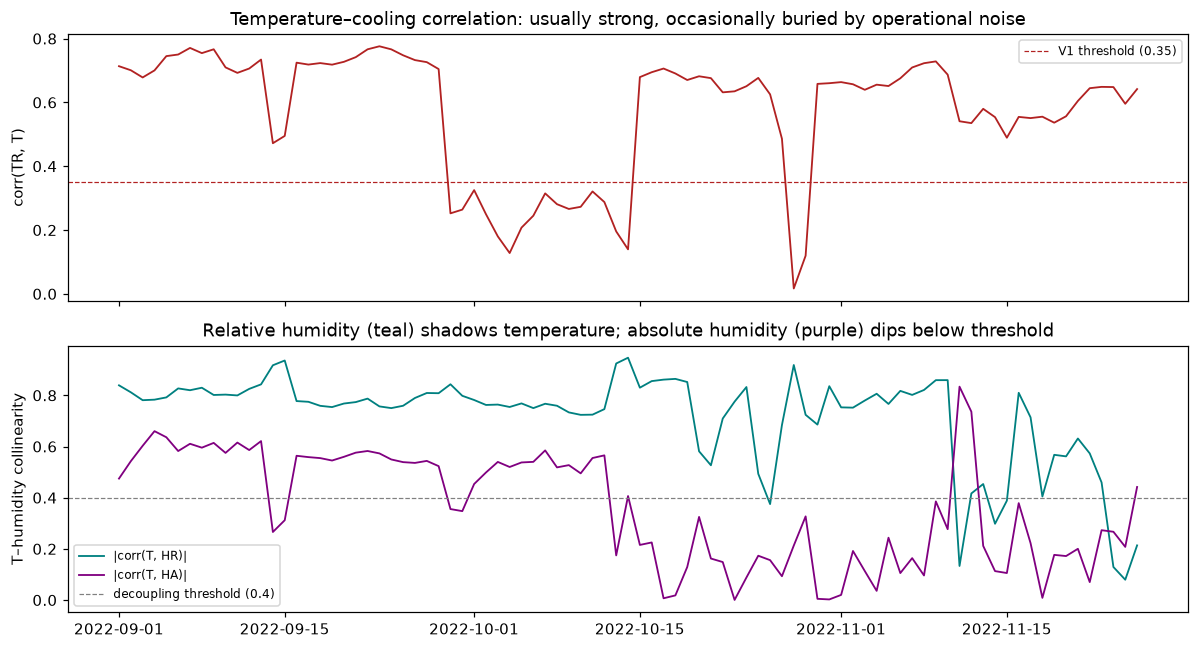

In [4]:
daily = sorted(df["timestamp"].dt.date.unique())
roll = []
for i, dd in enumerate(daily):
    lo, hi = daily[max(0,i-1)], daily[min(len(daily)-1,i+1)]
    w = df[(df["timestamp"].dt.date >= lo) & (df["timestamp"].dt.date <= hi)]
    if len(w) < 10: continue
    roll.append({"date": pd.Timestamp(dd),
                 "corr_TR_T": stats.pearsonr(w["TR"], w["T"])[0],
                 "corr_T_HR": abs(stats.pearsonr(w["T"], w["HR"])[0]),
                 "corr_T_HA": abs(stats.pearsonr(w["T"], w["HA"])[0])})
roll = pd.DataFrame(roll)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(roll["date"], roll["corr_TR_T"], color="firebrick", lw=1.2)
axes[0].axhline(V1_MIN, ls="--", c="firebrick", lw=0.8, label=f"V1 threshold ({V1_MIN})")
axes[0].set_ylabel("corr(TR, T)"); axes[0].legend(fontsize=8)
axes[0].set_title("Temperature–cooling correlation: usually strong, occasionally buried by operational noise")
axes[1].plot(roll["date"], roll["corr_T_HR"], color="teal",   lw=1.2, label="|corr(T, HR)|")
axes[1].plot(roll["date"], roll["corr_T_HA"], color="purple", lw=1.2, label="|corr(T, HA)|")
axes[1].axhline(CORR_MAX, ls="--", c="grey", lw=0.8, label=f"decoupling threshold ({CORR_MAX})")
axes[1].set_ylabel("T–humidity collinearity"); axes[1].legend(fontsize=8)
axes[1].set_title("Relative humidity (teal) shadows temperature; absolute humidity (purple) dips below threshold")
plt.tight_layout(); plt.show()

Top: temperature usually drives cooling time, with occasional stretches where operational
factors bury the signal. Bottom: relative humidity tracks temperature almost everywhere —
which is why estimating its independent effect is so hard — while absolute humidity
periodically decouples, opening a window to estimate *its* effect cleanly.

## 5. The regression family

In each period, five OLS models. The single-variable fits show what each variable explains
alone; the multiple models — `TR ~ T + HR` and `TR ~ T + HA` — show whether humidity adds
anything **once temperature is held constant**, which is the only test that isolates a
genuine humidity effect. We record each humidity coefficient's significance, but read it
with care: significance inside a hand-picked low-collinearity window is necessary, not
sufficient, evidence of a real operational effect.

In [5]:
def five_models(g):
    out = {}
    for key, f in [("T","TR~T"),("HR","TR~HR"),("HA","TR~HA"),("T_HR","TR~T+HR"),("T_HA","TR~T+HA")]:
        m = smf.ols(f, g).fit()
        out[f"R2_{key}"] = m.rsquared
        if key == "T_HR": out["beta_HR"], out["p_HR"] = m.params["HR"], m.pvalues["HR"]
        if key == "T_HA": out["beta_HA"], out["p_HA"] = m.params["HA"], m.pvalues["HA"]
    return out

model_rows = []
for g in blocks:
    r = five_models(g)
    model_rows.append({"period": g["period"].iloc[0], **{k: round(v,3) for k,v in r.items()}})
models = pd.DataFrame(model_rows).merge(classification[["period","scenarios"]], on="period")
models[["period","scenarios","R2_T","R2_HA","R2_T_HA","p_HA"]]

,period,scenarios,R2_T,R2_HA,R2_T_HA,p_HA
0,P1,V1,0.529,0.229,0.532,0.003
1,P2,V1,0.551,0.214,0.554,0.001
2,P3,V2,0.069,0.011,0.070,0.142
3,P4,"V1,V4",0.415,0.038,0.457,0.000
4,P5,"V1,V4",0.439,0.062,0.486,0.000
5,P6,"V1,V3,V4",0.309,0.161,0.483,0.000


### 5.1 R² by model and period

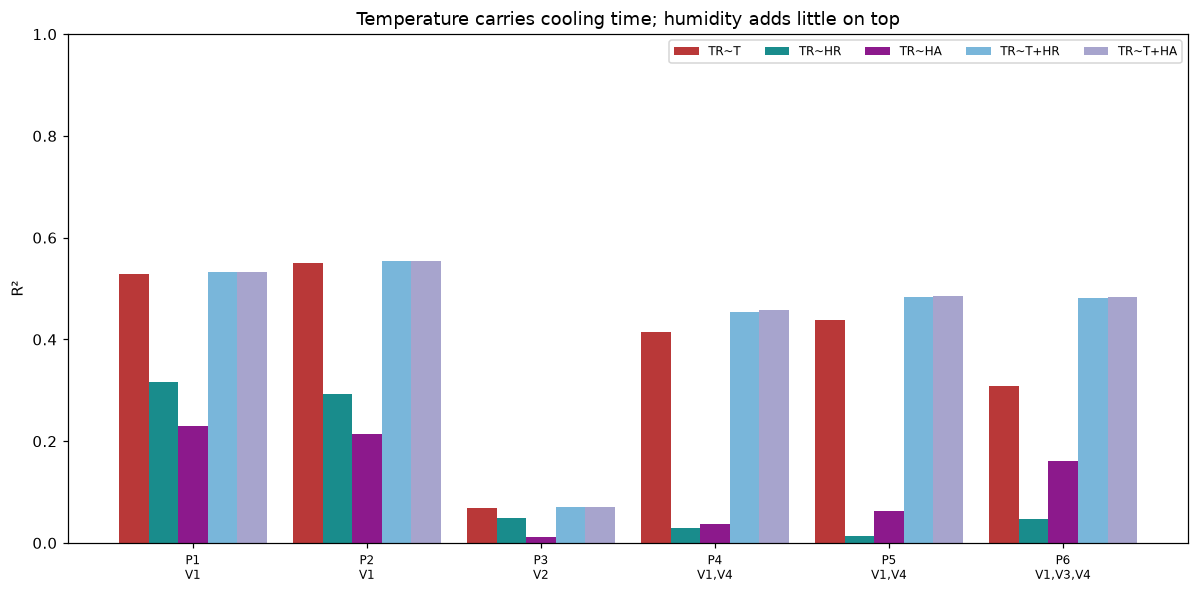

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(models)); w = 0.17
specs = [("R2_T","TR~T","firebrick"), ("R2_HR","TR~HR","teal"), ("R2_HA","TR~HA","purple"),
         ("R2_T_HR","TR~T+HR","#6baed6"), ("R2_T_HA","TR~T+HA","#9e9ac8")]
for i,(col,lab,c) in enumerate(specs):
    ax.bar(x + (i-2)*w, models[col], width=w, label=lab, color=c, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(models["period"]+"\n"+models["scenarios"], fontsize=8)
ax.set_ylabel("R²"); ax.set_ylim(0, 1)
ax.set_title("Temperature carries cooling time; humidity adds little on top")
ax.legend(ncol=5, fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

The red `TR~T` bar dominates in every period except the noise-buried one — temperature is
the driver throughout. Adding humidity (`TR~T+HA`, far right of each group) lifts R² only
slightly, and only where absolute humidity decouples. Humidity is a second-order correction,
never a competitor to temperature — the opposite of what a naive pooled `TR~HR` correlation
might suggest.

### 5.2 Does absolute humidity add anything once temperature is controlled?

In [7]:
v4 = models[models["scenarios"].str.contains("V4")].copy()
v4["R2_gain_from_HA"] = (v4["R2_T_HA"] - v4["R2_T"]).round(3)
print("V4 periods — absolute humidity's independent contribution (temperature already in the model):")
print(v4[["period","R2_T","R2_T_HA","R2_gain_from_HA","beta_HA","p_HA"]].to_string(index=False))
print("\nV2 period — for contrast, humidity is NOT significant where temperature is merely weak:")
v2 = models[models["scenarios"].str.contains("V2")]
print(v2[["period","R2_T","beta_HA","p_HA"]].to_string(index=False))

V4 periods — absolute humidity's independent contribution (temperature already in the model):
period  R2_T  R2_T_HA  R2_gain_from_HA  beta_HA  p_HA
    P4 0.415    0.457            0.042    2.998   0.0
    P5 0.439    0.486            0.047    3.297   0.0
    P6 0.309    0.483            0.174    3.199   0.0

V2 period — for contrast, humidity is NOT significant where temperature is merely weak:
period  R2_T  beta_HA  p_HA
    P3 0.069   -2.904 0.142


In the V4 periods, absolute humidity's coefficient is statistically significant and its
sign is consistent, adding a small but non-zero increment of explained variance *beyond*
temperature. In the V2 period — where temperature is merely weak — humidity is **not**
significant, confirming that a low temperature correlation reflects unmodelled operational
variance, not a hidden humidity effect. So there is a real signal, but it lives only inside
the strict V4 selection.

### 5.3 A closer look — relative humidity is mostly temperature in disguise

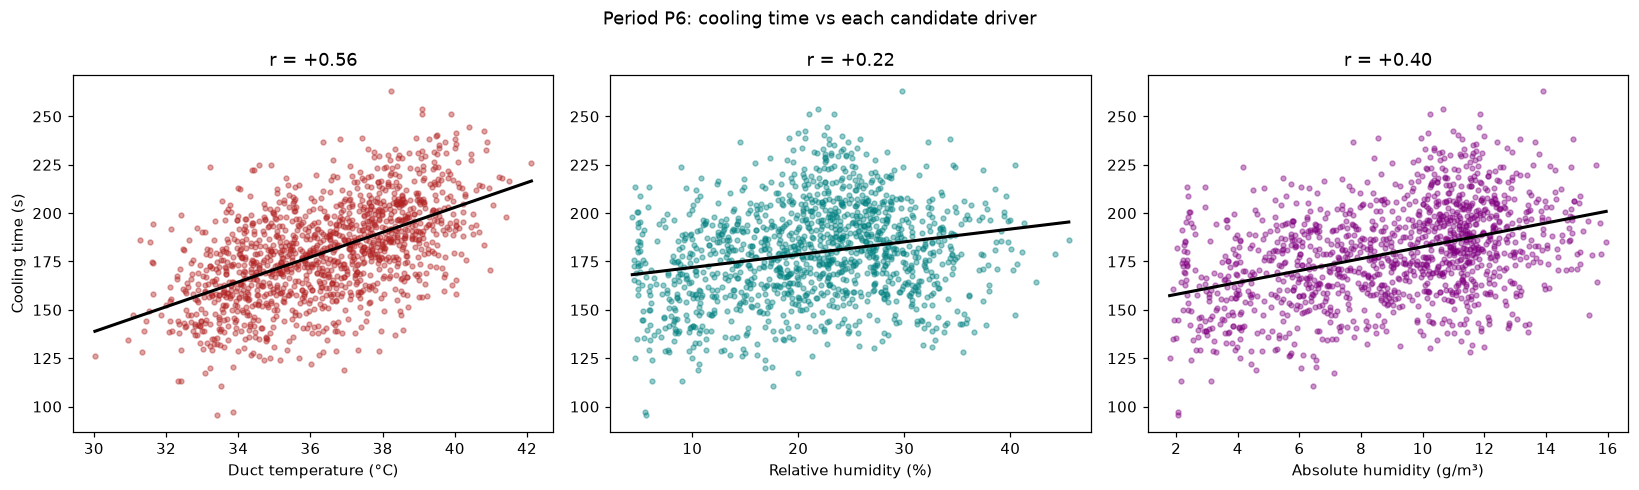

In [8]:
g6 = [b for b in blocks if b["period"].iloc[0] == "P6"][0]   # a period where both humidities decouple
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Period P6: cooling time vs each candidate driver", fontsize=12)
for ax,(col,xl,c) in zip(axes, [("T","Duct temperature (°C)","firebrick"),
                                 ("HR","Relative humidity (%)","teal"),
                                 ("HA","Absolute humidity (g/m³)","purple")]):
    ax.scatter(g6[col], g6["TR"], s=10, alpha=0.4, color=c)
    b1, b0 = np.polyfit(g6[col], g6["TR"], 1)
    xs = np.linspace(g6[col].min(), g6[col].max(), 40)
    ax.plot(xs, b0 + b1*xs, color="black", lw=2)
    ax.set_xlabel(xl); ax.set_title(f"r = {g6[col].corr(g6['TR']):+.2f}")
axes[0].set_ylabel("Cooling time (s)")
plt.tight_layout(); plt.show()

Temperature (left) carries the clearest trend. Absolute humidity (right) shows a mild but
real slope. Relative humidity (middle) looks related too — but Part 1 showed its variance is
largely temperature aliasing, so its apparent effect cannot be trusted as independent. This
is why the study privileges absolute humidity for any humidity claim.

## 6. Conclusion — a result, and an instrumentation decision

Reading the scenarios together:

- **Temperature governs cooling time.** V1 confirms it; it holds across the dataset.
- **A weak temperature correlation is not a humidity effect.** V2 shows that where
  temperature fades, humidity does not step in — the variance is unmodelled operational
  noise.
- **Relative humidity cannot be separated from temperature.** It aliases with it; clean V3
  periods barely exist, so any RH "effect" is largely temperature in disguise.
- **Absolute humidity shows a signal — but only inside the strict V4 selection.** Where it
  decouples from temperature, its coefficient is significant and independent. In normal
  operation, outside that constructed selection, no reliable humidity effect is visible.

**The honest conclusion is therefore not a number but a limit.** With the available
instrumentation — relative humidity measured in the control cabinet, absolute humidity
*computed* via Magnus rather than measured in the duct — a humidity effect on cooling time
**cannot be quantified reliably.** The signal that appears under V4 is enough to suspect a
real effect, not enough to act on.

What the study *does* deliver is the method that establishes this cleanly: a reproducible
pipeline, a scenario classification that controls collinearity, and a clear demonstration
that the ceiling here is **instrumental, not methodological**. That turns a non-result into
a concrete engineering recommendation:

> **Install direct absolute-humidity sensing in the cooling duct — first on a small set of
> pilot machines to verify the effect under real measurement, and, if confirmed, extend it
> across the plant.** Only measured (not computed) duct humidity can settle whether the
> effect is operationally meaningful.

**Part 3** (separate, and simpler) addresses the other lever for cooling-time stability: tuning
the pressure-regulation constant `K` to minimise the process's temperature sensitivity.